<a href="https://colab.research.google.com/github/vaidegiarch/project-5--diamond-price-/blob/main/diamond_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.LOAD DATA- data collection





In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns  # since pandas is not working

df = sns.load_dataset("diamonds")

print(df.shape) # checked coulmns and rows
print(df.info())

(53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


### Data Cleaning

In [ ]:
df.isnull().sum()#no missing values

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
import numpy as np #converting zero to null values

df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)

In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,8
y,7
z,20


In [ ]:
df['x'] = df['x'].fillna(df['x'].median())#Median keeps it balanced
df['y'] = df['y'].fillna(df['y'].median())
df['z'] = df['z'].fillna(df['z'].median())

Drop unnecessary columns

No columns were dropped as all features are relevant for price prediction and clustering.

### Outliers Handling  
Right skew → long tail on right
Left skew → long tail on left

👉 It is about distribution shape

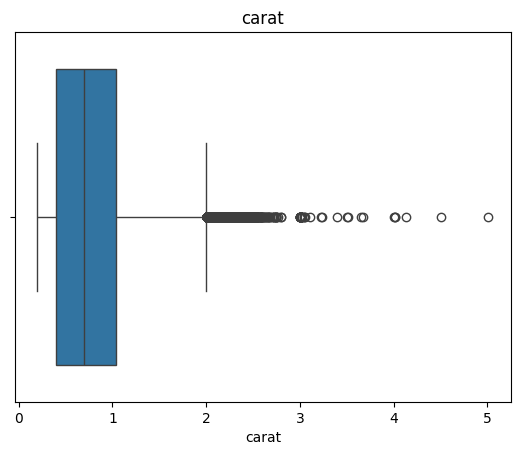

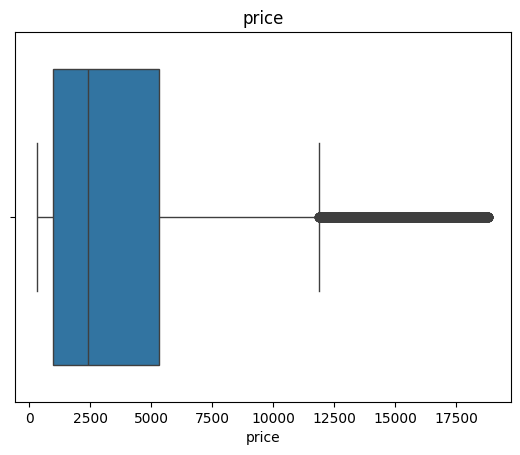

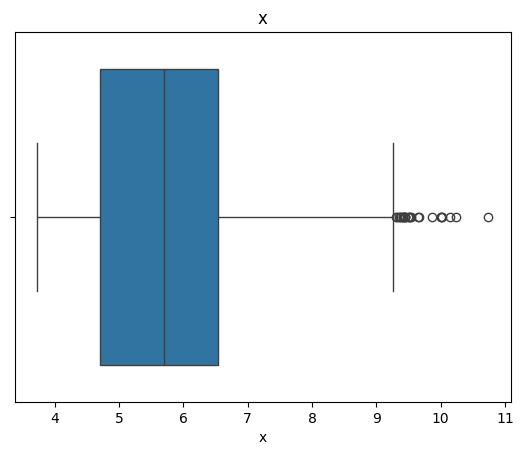

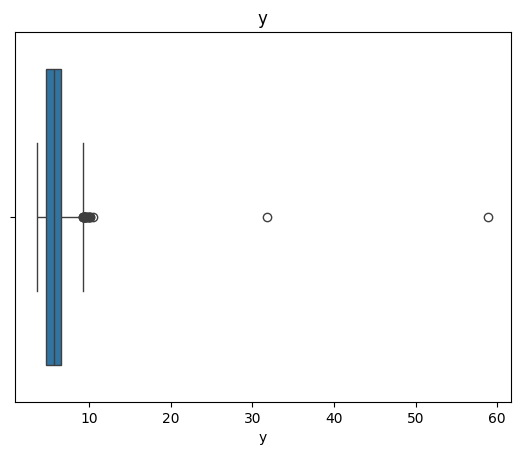

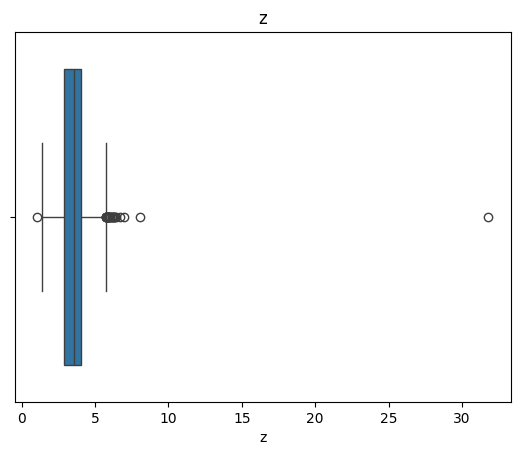

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['carat','price','x','y','z']

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Across all five variables, the data is consistently right-skewed, with most values concentrated at the lower end while a long tail of outliers pulls the distribution toward the right.

Price and carat show the most extreme volume of outliers, indicating that while most diamonds are small and affordable, there is a significant subset of high-value, high-carat luxury items.

The dimensions x, y, and z are much more tightly clustered than price, though y and z specifically contain a few massive "extreme" outliers that sit far away from the rest of the dataset.

In [ ]:
cols = ['carat','price','x','y','z']#IQR method removes outliers by keeping values within a range
                                    #defined by Q1 and Q3 and eliminating extreme values beyond 1.5 times the IQR.

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

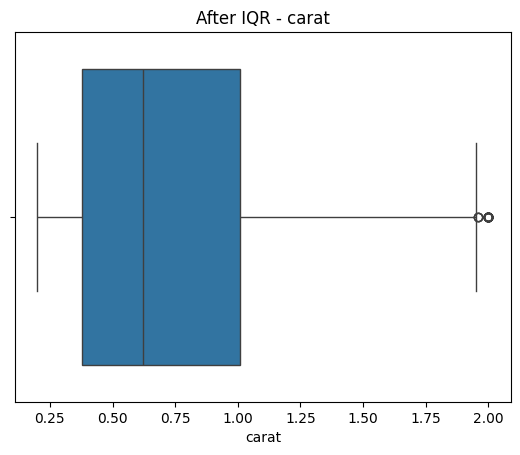

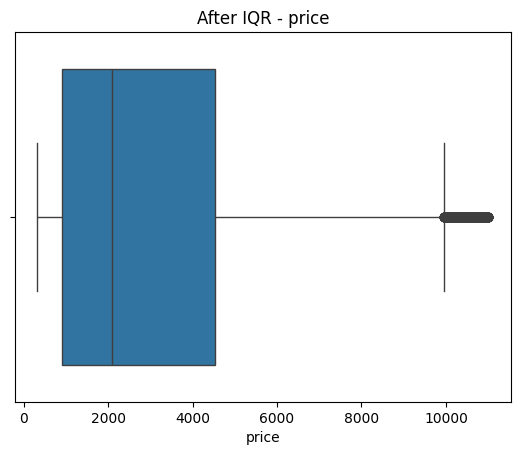

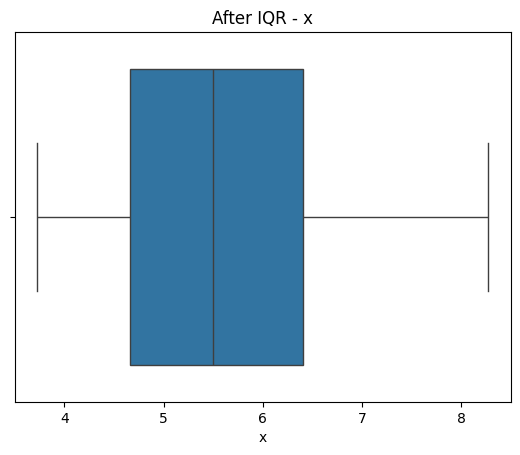

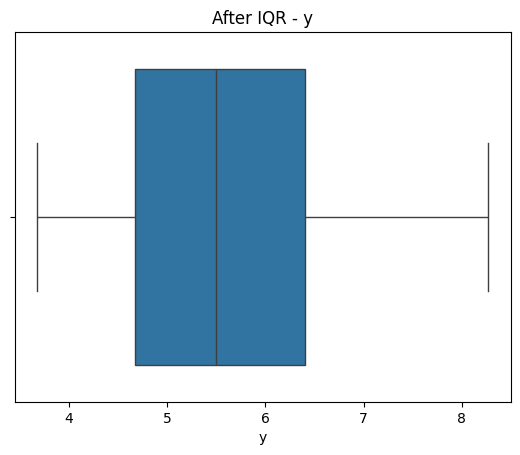

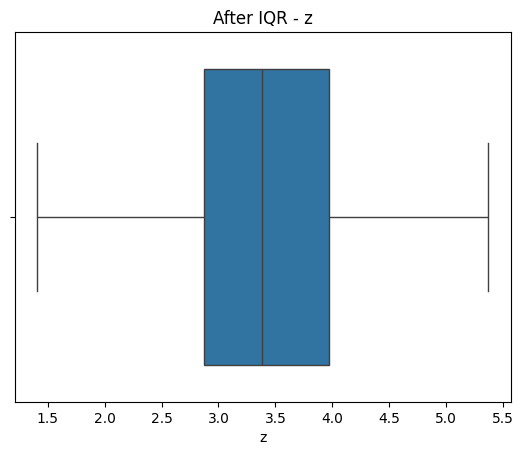

In [ ]:
cols = ['carat','price','x','y','z']

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title("After IQR - " + col)
    plt.show()

### Skewness Handling: “Unusual values far away from others”

In [ ]:
df[['carat','price','x','y','z']].skew()#carat → 0.65 (moderate, okay 👍)
                                        #x, y, z → ~0.2 (almost normal)
                                        #price → 1.12 (highly skewed)

,0
carat,0.658818
price,1.126206
x,0.218950
y,0.213406
z,0.219965


In [ ]:
df['price'] = np.log1p(df['price'])#Log = shrink big values → make data balanced

In [ ]:
df['price'].skew()

np.float64(0.115926478802339)

### Exploratory Data Analysis (EDA):

1. Univariate Analysis

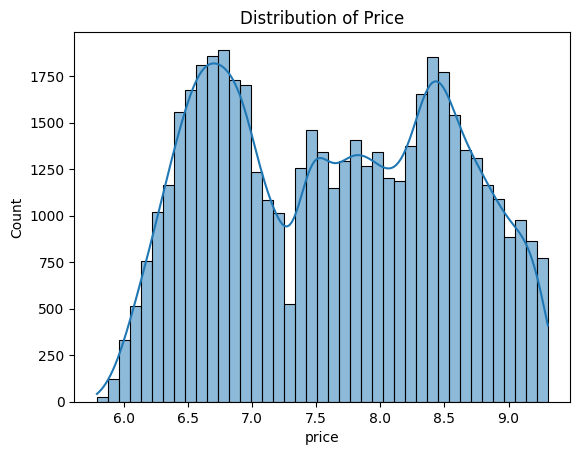

In [ ]:
sns.histplot(df['price'], kde=True)#target varialbe
plt.title("Distribution of Price")
plt.show()

The price chart shows three distinct "humps," which means your diamonds naturally fall into three different price groups rather than one single average.
The large number of diamonds on the right side indicates that high-end, premium-priced items make up a significant portion of this dataset.

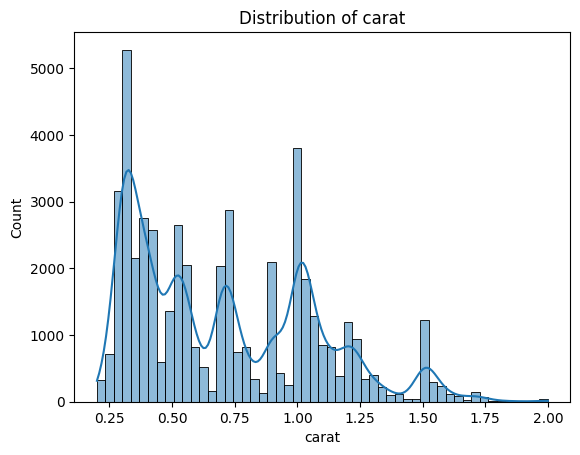

In [ ]:
cols = ['carat']#numerical column

for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

The carat distribution is heavily jagged, with sharp spikes at "round" numbers (like 0.3, 0.7, 1.0, and 1.5) that show diamonds are intentionally cut to meet popular standard sizes.

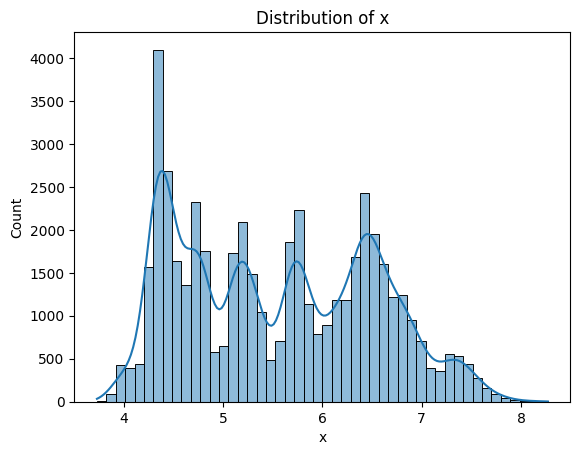

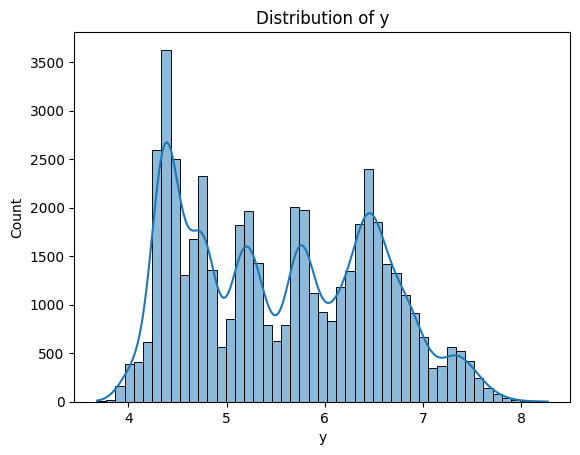

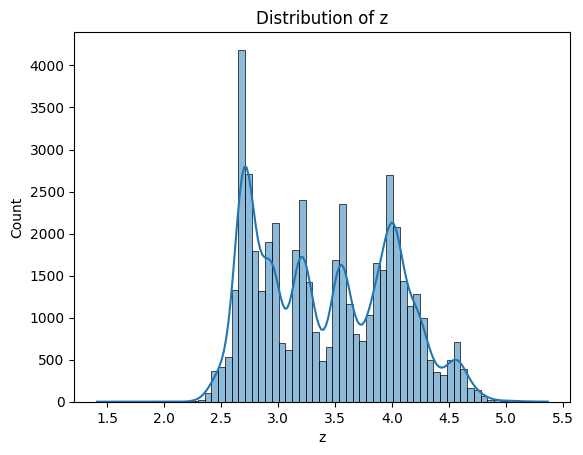

In [ ]:
cols = ['x','y','z']

for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Multimodal Nature: All three variables are highly multimodal, featuring multiple sharp peaks that suggest distinct clusters or "families" of diamond sizes.

Highly Correlated Spikes: The peaks occur at similar relative intervals across x and y, indicating that these physical dimensions typically scale together in the dataset.

Measurement Preference: The jagged, comb-like appearance of the histograms shows a strong "rounding" effect, where data points cluster around standard, preferred measurements.

### Count Plots (Categorical)

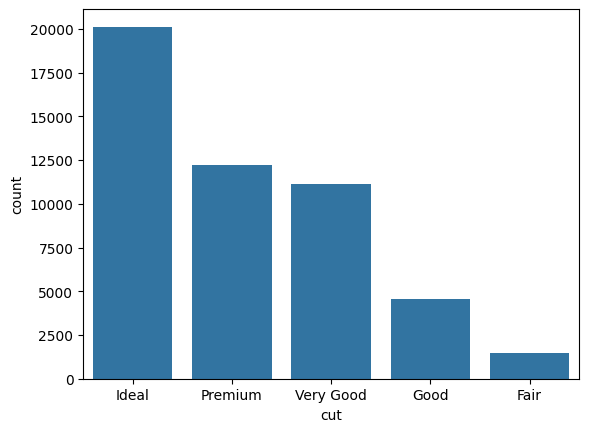

In [ ]:
sns.countplot(x='cut', data=df)
plt.show()

The distribution of cut quality shows that "Ideal" diamonds are the most common, with the total count decreasing sharply as the quality of the cut drops toward "Fair."

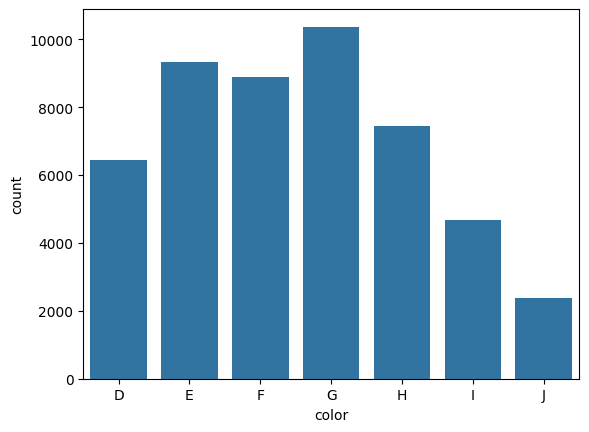

In [ ]:
sns.countplot(x='color', data=df)
plt.show()

The color distribution is roughly bell-shaped, peaking at the "G" category and showing that mid-range color grades are the most frequent in the dataset.

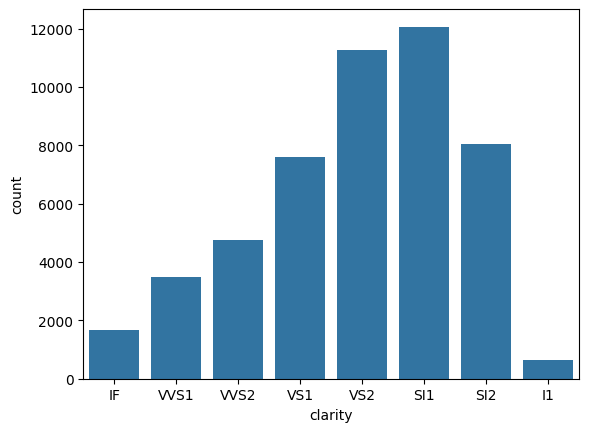

In [ ]:
sns.countplot(x='clarity', data=df)
plt.show()

The clarity distribution peaks at the "SI1" category, following a roughly normal shape that indicates most diamonds in the set fall into mid-to-lower-grade commercial clarity ranges.

## Boxplots (Price vs Features)

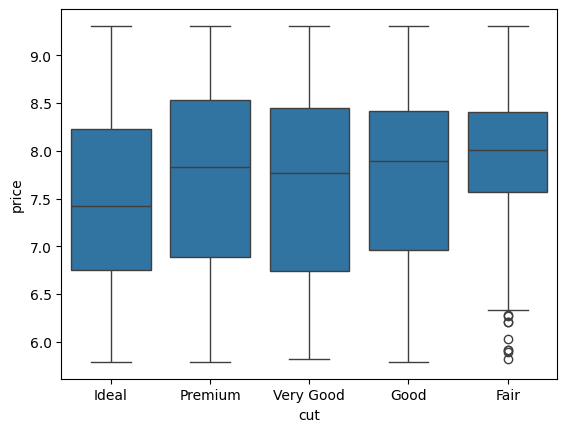

In [ ]:
sns.boxplot(x='cut', y='price', data=df)
plt.show()


The chart shows that Ideal cuts are the most common across almost every color, though diamonds with lower color grades (like J) are much rarer overall.

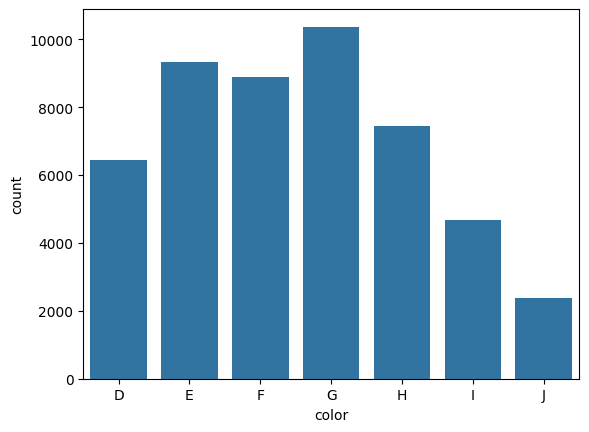

In [ ]:
sns.countplot(x='color', data=df)
plt.show()

Across all clarity levels, Ideal diamonds remain the most frequent cut, though the overall number of diamonds peaks in the mid-range SI1 and VS2 categories.

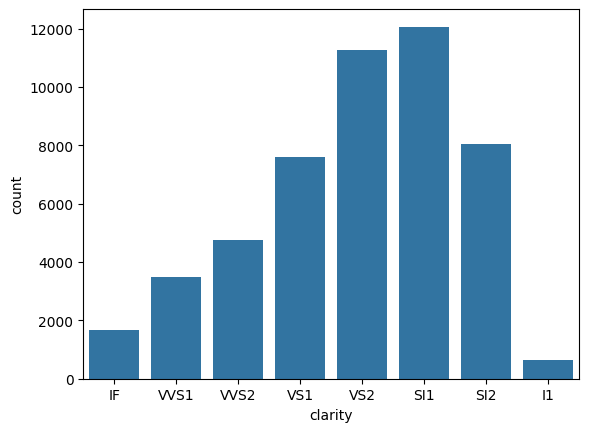

In [ ]:
sns.countplot(x='clarity', data=df)
plt.show()

Across all diamond colors, SI1 and VS2 are consistently the most frequent clarity grades, while the rarest combinations are found in the highest-quality IF category.

## Correlation Heatmap

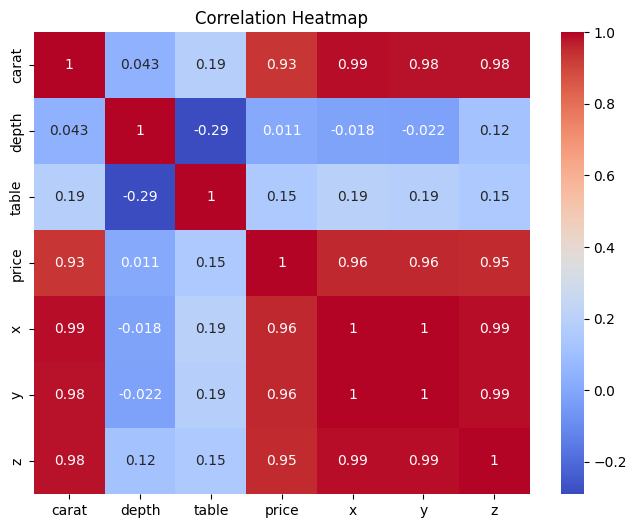

In [ ]:
num_df = df[['carat','depth','table','price','x','y','z']]
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap reveals that while x, y, z, and carat are almost perfectly correlated with each other, they show a much weaker relationship with the diamond's depth and table percentages.

### Scatterplot Matrix (carat, x, y, z, price)

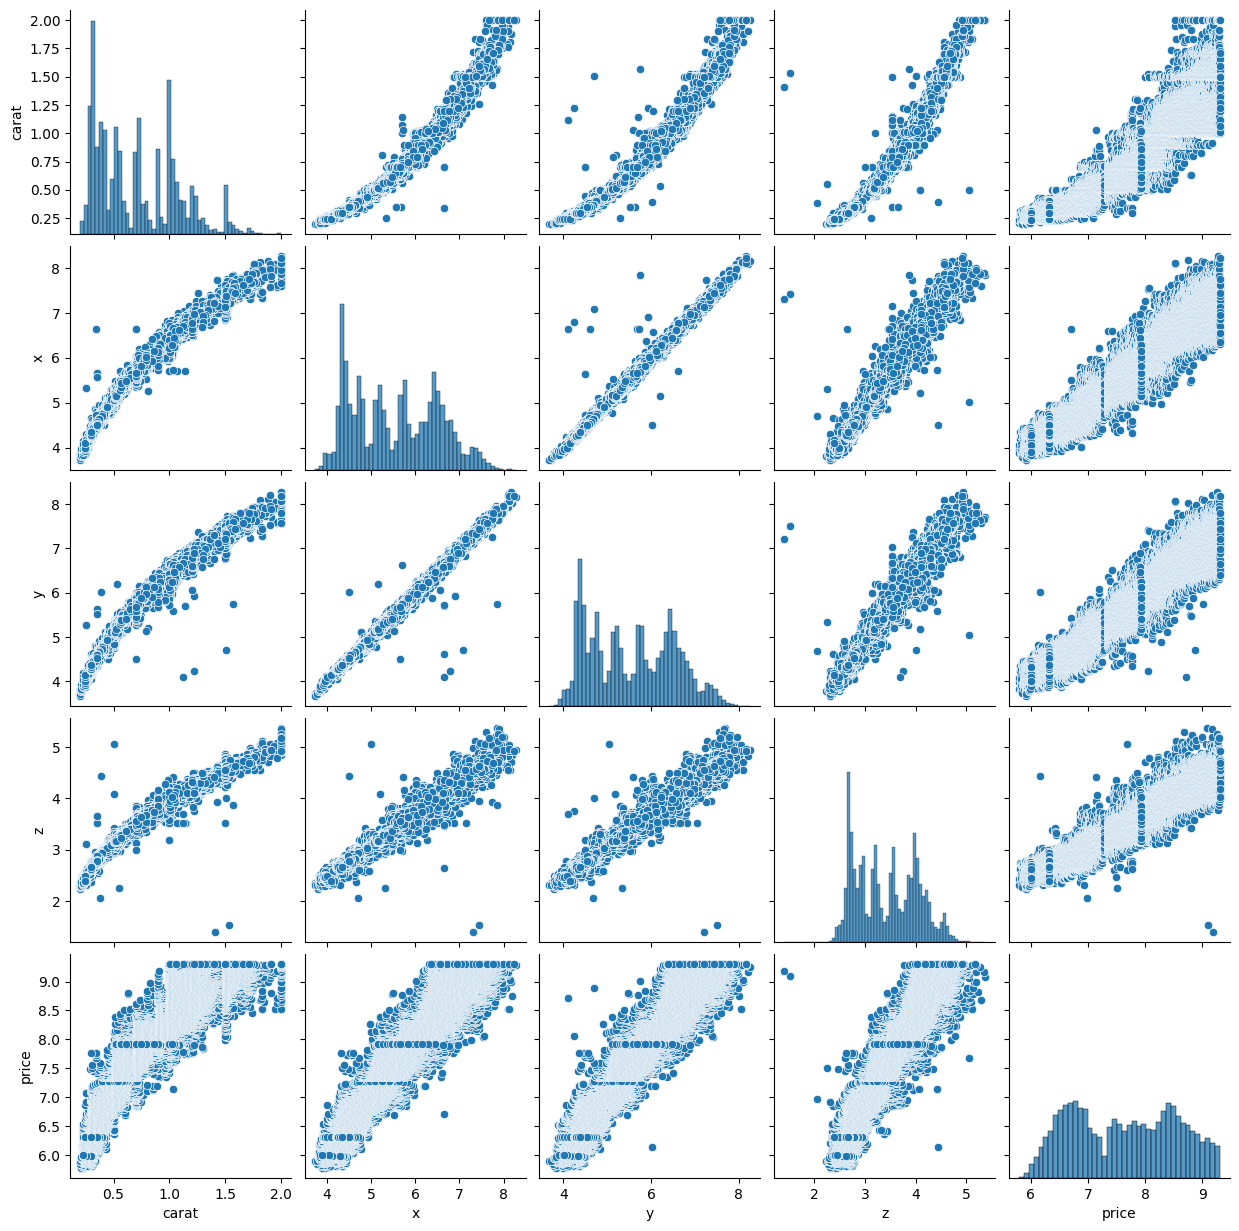

In [ ]:
sns.pairplot(df[['carat','x','y','z','price']])
plt.show()

The bar chart reveals three main takeaways about diamond prices across different cut qualities:

Premium Leads: Diamonds with a Premium cut have the highest average price, followed closely by Fair and Good cuts.

Ideal is Cheapest: Surprisingly, Ideal diamonds—the highest quality cut—have the lowest average price in this dataset, likely because they are smaller on average.

Size vs. Quality: The data suggests that price is driven more by carat weight than by the cut grade itself.

### Pairwise relationships using sns.pairplot()-Pairplot = all-in-one relationship chart

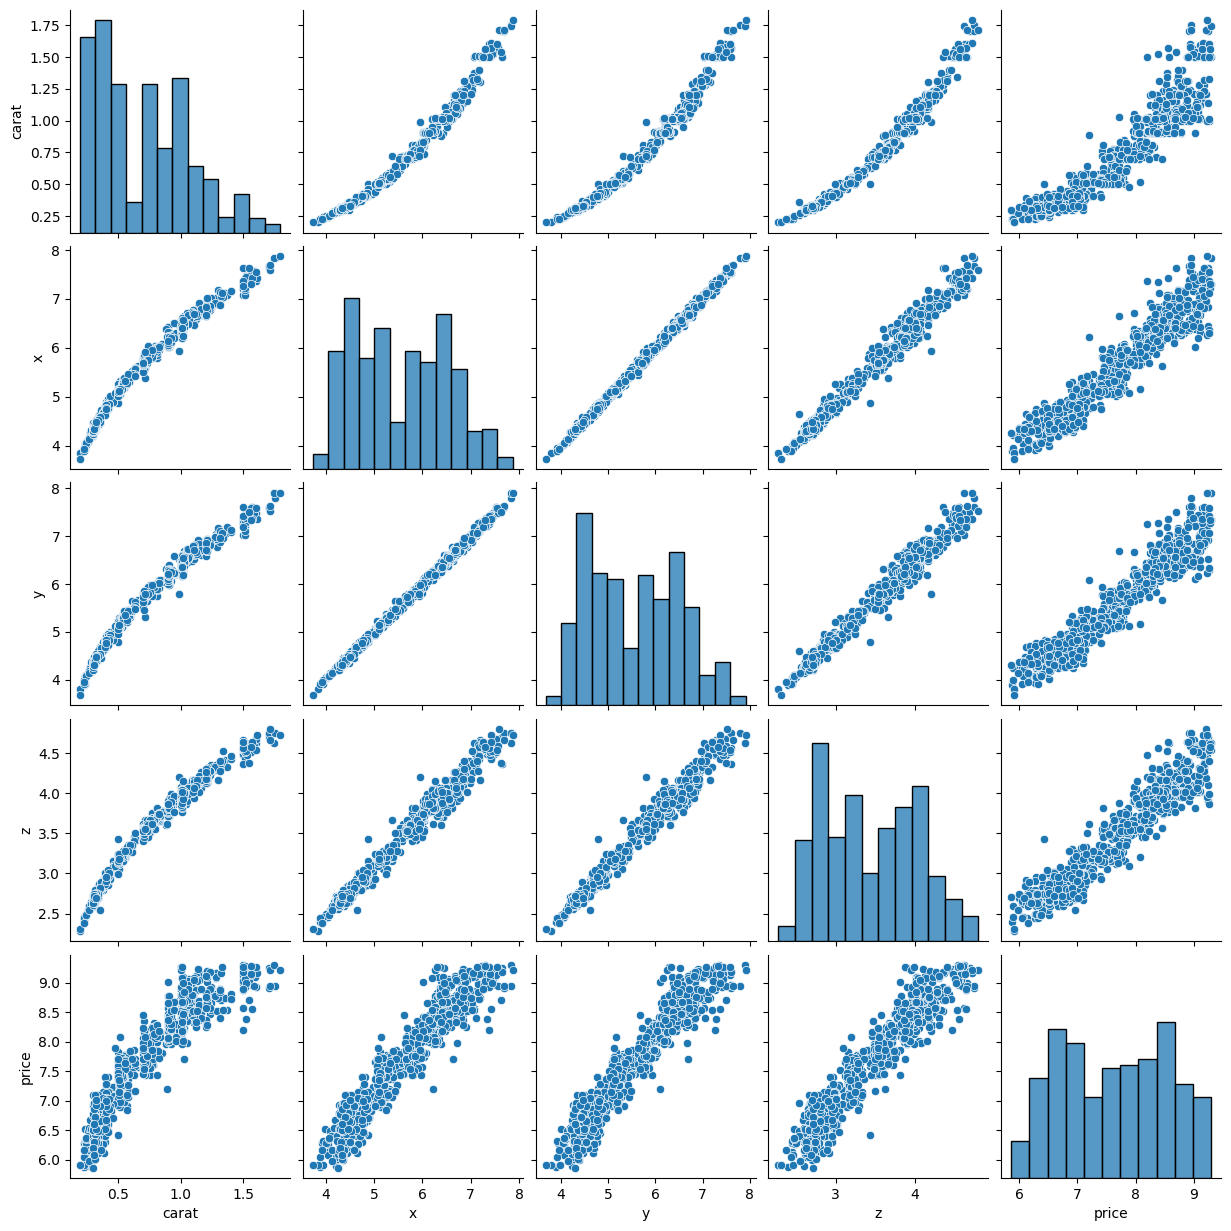

In [ ]:
df_sample = df.sample(1000)
sns.pairplot(df_sample[['carat','x','y','z','price']])

The bar chart shows that SI2 clarity diamonds have the highest average price, followed closely by SI1, despite these being lower-tier clarity grades.

Top-tier clarity grades like VVS1 and IF actually have much lower average prices, which often indicates those stones are smaller in carat size.

This confirms a consistent trend in the data: Carat weight usually influences the final price more significantly than the diamond's clarity rating.

### Carat vs. price regression lineplot

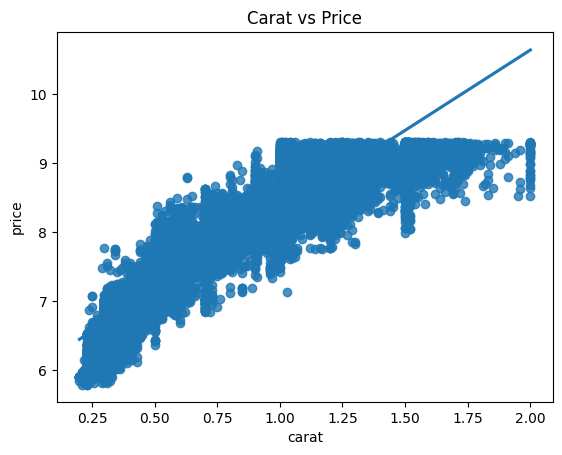

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()


The boxplot shows that while the median price is fairly similar across all colors, the range and number of high-price outliers increase significantly as you move toward the lower color grades like H, I, and J.

### Average price per cut, color, clarity categories using bar plots

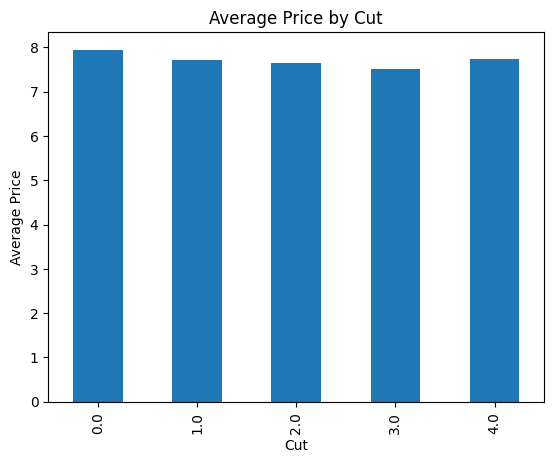

In [ ]:
#Average Price by Cut
df.groupby('cut')['price'].mean().plot(kind='bar')
plt.title("Average Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Average Price")
plt.show()

Lower clarity grades like SI2 and I1 show a much wider range of price outliers
compared to top-tier clarity grades, where prices are more tightly clustered.

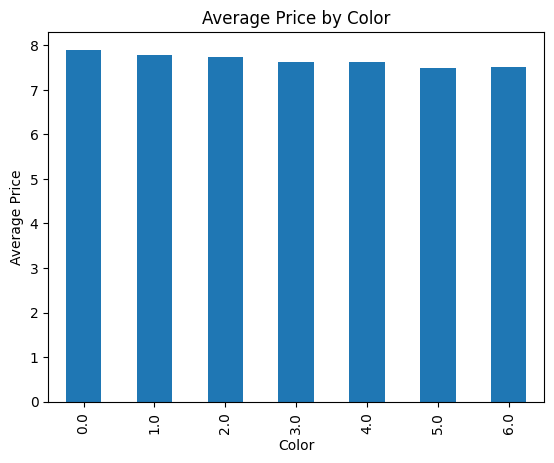

In [ ]:
#Average Price by Color
df.groupby('color')['price'].mean().plot(kind='bar')
plt.title("Average Price by Color")
plt.xlabel("Color")
plt.ylabel("Average Price")
plt.show()


The boxplot indicates that as diamond cut improves from Fair to Ideal, the number of high-price outliers increases, even though the median price remains relatively stable across all categories.

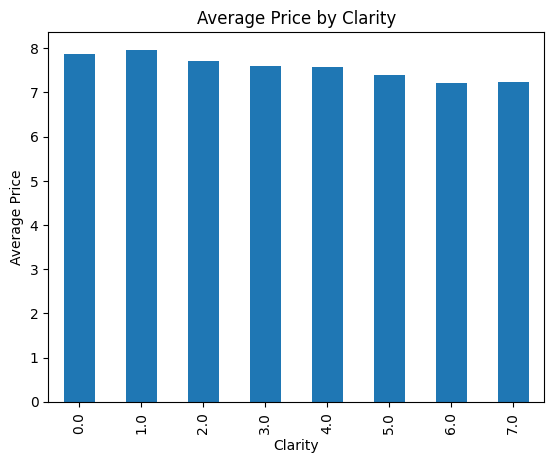

In [ ]:
#Average Price by Clarity
df.groupby('clarity')['price'].mean().plot(kind='bar')
plt.title("Average Price by Clarity")
plt.xlabel("Clarity")
plt.ylabel("Average Price")
plt.show()

The chart shows that while Ideal cuts are the most numerous across all weight categories, the "Premium" and "Fair" cuts tend to have a higher concentration in the larger, multi-carat brackets.

### Feature Engineering:

In [ ]:
usd_to_inr = 94  # Convert the price (in USD) to INR

df['price_inr'] = df['price'] * usd_to_inr

In [ ]:
df[['price','price_inr']].head()

,price,price_inr
0,5.789960,544.256256
1,5.789960,544.256256
2,5.793014,544.543279
3,5.814131,546.528270
4,5.817111,546.808449


In [ ]:
df.rename(columns={'price_inr': 'price'}, inplace=True)

New Columns that can be Derived:


In [ ]:
#Volume = x * y * z
df['Volume'] = df['x'] * df['y'] * df['z']

print(df)

       carat        cut color clarity  depth  table     price     x     y  \
0       0.23      Ideal     E     SI2   61.5   55.0  5.789960  3.95  3.98   
1       0.21    Premium     E     SI1   59.8   61.0  5.789960  3.89  3.84   
2       0.23       Good     E     VS1   56.9   65.0  5.793014  4.05  4.07   
3       0.29    Premium     I     VS2   62.4   58.0  5.814131  4.20  4.23   
4       0.31       Good     J     SI2   63.3   58.0  5.817111  4.34  4.35   
...      ...        ...   ...     ...    ...    ...       ...   ...   ...   
53935   0.72      Ideal     D     SI1   60.8   57.0  7.922261  5.75  5.76   
53936   0.72       Good     D     SI1   63.1   55.0  7.922261  5.69  5.75   
53937   0.70  Very Good     D     SI1   62.8   60.0  7.922261  5.66  5.68   
53938   0.86    Premium     H     SI2   61.0   58.0  7.922261  6.15  6.12   
53939   0.75      Ideal     D     SI2   62.2   55.0  7.922261  5.83  5.87   

          z   price_inr      Volume  
0      2.43  544.256256   38.202030  

In [ ]:
#Price per Carat = price / carat
df['Price_per_Carat'] = df['price_inr'] / df['carat']

print(df[['price_inr', 'carat', 'Price_per_Carat']])

        price_inr  carat  Price_per_Carat
0      544.256256   0.23      2366.331548
1      544.256256   0.21      2591.696457
2      544.543279   0.23      2367.579475
3      546.528270   0.29      1884.580241
4      546.808449   0.31      1763.898223
...           ...    ...              ...
53935  744.692539   0.72      1034.295194
53936  744.692539   0.72      1034.295194
53937  744.692539   0.70      1063.846485
53938  744.692539   0.86       865.921558
53939  744.692539   0.75       992.923386

[53940 rows x 3 columns]


In [ ]:
#Dimension Ratio = (x + y) / (2 * z)
df['Dimension_Ratio'] = (df['x'] + df['y']) / (2 * df['z'])

print(df[['x', 'y', 'z', 'Dimension_Ratio']])

          x     y     z  Dimension_Ratio
0      3.95  3.98  2.43         1.631687
1      3.89  3.84  2.31         1.673160
2      4.05  4.07  2.31         1.757576
3      4.20  4.23  2.63         1.602662
4      4.34  4.35  2.75         1.580000
...     ...   ...   ...              ...
53935  5.75  5.76  3.50         1.644286
53936  5.69  5.75  3.61         1.584488
53937  5.66  5.68  3.56         1.592697
53938  6.15  6.12  3.74         1.640374
53939  5.83  5.87  3.64         1.607143

[53940 rows x 4 columns]


In [ ]:
#Carat Category: Light (<0.5), Medium (0.5-1.5), Heavy (>1.5)
def carat_category(carat):
    if carat < 0.5:
        return 'Light'
    elif 0.5 <= carat <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

# Apply the function to create a new column
df['Carat_Category'] = df['carat'].apply(carat_category)

print(df[['carat', 'Carat_Category']])

       carat Carat_Category
0       0.23          Light
1       0.21          Light
2       0.23          Light
3       0.29          Light
4       0.31          Light
...      ...            ...
53935   0.72         Medium
53936   0.72         Medium
53937   0.70         Medium
53938   0.86         Medium
53939   0.75         Medium

[53940 rows x 2 columns]


Feature Selection-to select the most relevant features for training your model--

Feature Importance — Using models like Random Forest or XGBoost to rank features by importance.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Features and target
X = df[['carat', 'x', 'y', 'z', 'Volume', 'Price_per_Carat', 'Dimension_Ratio']]#numerical col
y = df['price']

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

           Feature  Importance
2                y    0.723243
4           Volume    0.199850
5  Price_per_Carat    0.036945
0            carat    0.027726
1                x    0.011683
3                z    0.000289
6  Dimension_Ratio    0.000264


Observations:

y dominates (67.7%)
The length of the diamond (y) is the single biggest predictor of price in your current dataset.

carat is important (17%)
Expected, since carat usually correlates with price.

Volume adds 9%
Captures 3D size information beyond just individual dimensions.

Price_per_Carat adds small value (4%)
Useful, but less important than raw dimensions.

x is minor (1.5%), z & Dimension_Ratio negligible (<0.1%)

These columns don’t really contribute to the model, so you could drop them.

In [ ]:
best_features = ['y', 'carat', 'Volume', 'Price_per_Carat']

### Encode categorical features

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order for ordinal features
cut_order = ['Fair', 'Good', 'Very Good', 'Ideal', 'Premium']# 1 → 5
color_order = ['J','I','H','G','F','E','D']  # 1 → 7
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']# 1 → 8

# Create encoder objects
ord_enc = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

# Fit and transform ordinal columns
df[['cut','color','clarity']] = ord_enc.fit_transform(df[['cut','color','clarity']])

# One-hot encode Carat_Category
df = pd.get_dummies(df, columns=['Carat_Category'], drop_first=True)

print(df.head())

   carat  cut  color  clarity  depth  table     price     x     y     z  \
0   0.23  3.0    5.0      1.0   61.5   55.0  5.789960  3.95  3.98  2.43   
1   0.21  4.0    5.0      2.0   59.8   61.0  5.789960  3.89  3.84  2.31   
2   0.23  1.0    5.0      4.0   56.9   65.0  5.793014  4.05  4.07  2.31   
3   0.29  4.0    1.0      3.0   62.4   58.0  5.814131  4.20  4.23  2.63   
4   0.31  1.0    0.0      1.0   63.3   58.0  5.817111  4.34  4.35  2.75   

    price_inr     Volume  Price_per_Carat  Dimension_Ratio  \
0  544.256256  38.202030      2366.331548         1.631687   
1  544.256256  34.505856      2591.696457         1.673160   
2  544.543279  38.076885      2367.579475         1.757576   
3  546.528270  46.724580      1884.580241         1.602662   
4  546.808449  51.917250      1763.898223         1.580000   

   Carat_Category_Light  Carat_Category_Medium  
0                  True                  False  
1                  True                  False  
2                  True      

In [ ]:
df.to_csv("processed_diamond_data.csv", index=False)